# 06. Two-atom `01r` adiabatic pulse optimization

This notebook constructs, optimizes, and validates a smooth two-atom
computational-return pulse in the effective `01r` model. The pulse may populate
Rydberg states during the gate; it is accepted only when all four logical
inputs return with

$$
L_{\max}\le 10^{-4},\qquad
C_\phi=\left|\sin\tfrac{\Phi_{ZZ}}{2}\right|\ge 0.5 .
$$

`ryd_gate` supplies the physical system, the exported bilinear control model,
and the exact evolution; `qoc` supplies the optimizer and the discrete-adjoint
GRAPE engine. The gate objective, continuation, diagnostics, and persistence
stay explicit here — the study is the only glue between the two packages.

**Run All has one cache switch, `FORCE_RECOMPUTE`:**

- if `results/01r_adiabatic_optimization/result.json` exists with the current
  schema and `FORCE_RECOMPUTE` is `False`, the notebook **loads** it and
  rebuilds `history` and `stages` from JSON, then goes straight to the summary
  and figures with no `minimize`, `simulate`, or ARC work;
- otherwise it optimizes the three $T=2\,\mu\mathrm{s}$ seeds, exact-validates
  each selected pulse with public `simulate(..., backend="exact_ode")`, and
  atomically writes `result.json` (incrementally, after every branch) before
  plotting;
- `FORCE_RECOMPUTE=True` deliberately replaces the cached result with a new run.

Duration continuation is a separate opt-in (`RUN_CONTINUATION`, section 9): a
fixed-step duration ladder from $1.9\,\mu\mathrm{s}$ down to
$0.5\,\mu\mathrm{s}$ that never stalls. The exact
validation is intentionally complete: it evolves `00`, `01`, `10`, and `11`
rather than invoking exchange symmetry.

## 1. Setup and user controls

Angular frequencies are stored in rad/s and displayed in MHz after division by
$2\pi$. Geometry is fixed by a two-site `Register.chain` with $4\,\mu\mathrm{m}$
spacing; the `01r` level structure supplies the signed ARC $70S$ interaction.

In [1]:
from __future__ import annotations

import json
import sys
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython import get_ipython
from IPython.display import Markdown, display
from matplotlib import cm, colors
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import BSpline

ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import qoc  # noqa: E402
from qoc import grape  # noqa: E402
from ryd_gate import (  # noqa: E402
    Register,
    RydbergSystem,
    bilinear_control_model,
    level_structure,
    simulate,
)
from ryd_gate.physics import arc_pair_c6_rad_s_um6  # noqa: E402
from ryd_gate.protocols import DigitalAnalogProtocol, SweepProtocol, phase_from_chirp  # noqa: E402

# Embed figures as inline PNGs under a Jupyter kernel (a no-op in a plain
# interpreter); keeps this notebook pure-Python source with no %magic.
_ipython = get_ipython()
if _ipython is not None:
    from IPython.core.pylabtools import select_figure_formats

    select_figure_formats(_ipython, {"png"})

TWOPI = 2.0 * np.pi
MHz = TWOPI * 1e6

# One cache switch. False: load result.json if present and replot with no
# optimizer / exact_ode / ARC work. True: recompute and atomically replace it.
FORCE_RECOMPUTE = False
# The duration-ladder continuation is a separate explicit opt-in (section 9):
# fixed 0.1 us steps from 1.9 us down to 0.5 us; it never stalls, and each stage
# is marked accepted/failed so the inherited-seed objective jumps at every
# duration decrease stay visible.
RUN_CONTINUATION = False
RESULT_PATH = ROOT / "results" / "01r_adiabatic_optimization" / "result.json"

# Physical bounds and acceptance criteria.
SPACING_UM = 4.0
RYD_LEVEL = 70
A_MAX = 17.0 * MHz
CHI_MAX = 20.0 * MHz
EDGE_CHIRP_MIN = 5.0 * MHz
L_MAX_ACCEPT = 1e-4
C_PHI_ACCEPT = 0.5
S_PHI_MIN = C_PHI_ACCEPT**2

# Search and validation settings. The 1 ns piecewise-constant midpoint step
# reproduces the previous CF4 engine's endpoint amplitudes to ~2e-5 on the
# seed pool, far below both acceptance thresholds.
INITIAL_DURATION_S = 2.0e-6
LADDER_STEP_S = 0.1e-6
LADDER_MIN_DURATION_S = 0.5e-6
PW_MAX_STEP_S = 1.0e-9
PHASE_SAMPLES = 4001
EXACT_TRAJECTORY_POINTS = 301
EXACT_OPTIONS = {"hamiltonian_format": "dense", "rtol": 1e-10, "atol": 1e-12}
OPTIMIZER_OPTIONS = {"maxiter": 50, "maxfun": 100, "gtol": 1e-8, "ftol": 1e-14, "maxls": 20}
SCHEMA_VERSION = 4

SEED_SPECS = (
    {"branch": "phase_near_pi", "amplitude_MHz": 13.0, "edge_chirp_MHz": 15.0},
    {"branch": "negative_phase", "amplitude_MHz": 14.0, "edge_chirp_MHz": 12.0},
    {"branch": "positive_phase", "amplitude_MHz": 10.0, "edge_chirp_MHz": 13.0},
)
LOGICAL_LABELS = (["0", "0"], ["0", "1"], ["1", "0"], ["1", "1"])

REGISTER = Register.chain(2, spacing_um=SPACING_UM)

## 2. Physical two-atom model

For the local order $(0,1,r)$, the search Hamiltonian is

$$
H(t)=V_{rr}\,n_{r,0}n_{r,1}
+\tfrac{A(t)}{2}\sum_i\left(|r\rangle_i\langle1|+\mathrm{h.c.}\right)
-\chi(t)\sum_i n_{r,i}.
$$

The public protocol uses the complex $1\!-\!r$ matrix element
$H_{r1}=\tfrac{A(t)}{2}e^{-i\phi(t)}$, with $\dot\phi=\chi$. The diagonal
$-\chi\,n_r$ is only the rotating-frame form used by GRAPE; because the four
computational inputs carry no Rydberg population at either endpoint, the two
frames give identical logical amplitudes. Exact validation therefore uses the
complex drive and does **not** set `energy_r_rad_s`.

The search matrices come from `ryd_gate.bilinear_control_model`: driving the
`E[r,1]:x` quadrature with $A/2$ and the `E[r,r]` channel with $-\chi$
reproduces exactly this Hamiltonian, with $h_0$ supplying the signed ARC $70S$
blockade. The model and the ARC interaction are resolved only on a fresh
compute; a cached replay reads $V_{rr}$ from the stored config.

In [2]:
def resolve_interaction():
    """Signed ARC 70S pair interaction (rad/s). Called only on a fresh compute."""
    c6 = arc_pair_c6_rad_s_um6(
        n1=RYD_LEVEL, l1=0, j1=0.5, mj1=-0.5, mj2=-0.5,
        theta=0.0, phi=0.0, degenerate=False,
    )
    return float(c6), float(c6) / SPACING_UM**6


def build_search_model():
    """Search-side bilinear control model exported from ryd_gate (ADR-0024).

    The reference protocol carries zero coefficients: it only fixes the
    channel structure (the E[r,1] quadratures and the E[r,r] detuning
    channel). The search drives the x quadrature with A/2 and the diagonal
    channel with -chi; h0 carries the geometry-resolved blockade, so the same
    compiler that serves exact validation supplies the search matrices.
    """
    reference = SweepProtocol(
        t_gate_s=INITIAL_DURATION_S,
        omega_half_rad_s=lambda t: 0.0,
        detuning_rad_s=lambda t: 0.0,
    )
    system = RydbergSystem(
        level_structure=level_structure("01r", ryd_level=RYD_LEVEL),
        register=REGISTER, protocol=reference)
    h0, channels, states = bilinear_control_model(system, states=list(LOGICAL_LABELS))
    initial_states = [states[tuple(labels)] for labels in LOGICAL_LABELS]
    return {
        "h0": h0,
        "controls": {name: channels[name] for name in ("E[r,1]:x", "E[r,r]")},
        "initial_states": initial_states,
        "indices": [int(np.argmax(np.abs(vec))) for vec in initial_states],
        "dim": int(h0.shape[0]),
    }

## 3. Bounded 17-coordinate pulse

Let $s=t/T$. The analytic seed is
$A_{\rm seed}(s)=A_0E(s)$ and $\chi_{\rm seed}(s)=-D_{\rm edge}\cos(2\pi s)$,
where $E(s)$ is a 15% quintic rise, flat top, and symmetric fall.

Eight nonnegative cubic B-splines form a partition of unity:

$$
A(s)=A_{\max}E(s)\sum_{k=1}^{8}p_kB_k(s),\qquad 0\le p_k\le1,\quad
A_{\max}/2\pi=17\ \mathrm{MHz}.
$$

The chirp uses a bounded seed-preserving map:

$$
x=-\eta\cos(2\pi s),\quad
v=\tanh\!\Big(E(s)\sum_k d_kB_k(s)\Big),\quad
\frac{\chi(s)}{\chi_{\max}}=\frac{x+v}{1+xv},
$$

with $\chi_{\max}/2\pi=20$ MHz, $\eta=D_{\rm edge}/\chi_{\max}\in[0.25,1]$, and
$d_k\in[-3,3]$. The search has $8+8+1=17$ coordinates, exactly restores the
analytic seed at $d_k=0$, forces a common nonzero endpoint chirp $\ge 5$ MHz,
and vanishing coupling at both endpoints.

In [3]:
def power_envelope(s):
    """15% quintic rise, flat top, and symmetric fall."""
    s = np.asarray(s, dtype=float)
    out = np.ones_like(s)
    rise = 0.15

    left = s < rise
    x = np.clip(s[left] / rise, 0.0, 1.0)
    out[left] = 10 * x**3 - 15 * x**4 + 6 * x**5

    right = s > 1.0 - rise
    x = np.clip((1.0 - s[right]) / rise, 0.0, 1.0)
    out[right] = 10 * x**3 - 15 * x**4 + 6 * x**5
    return out.item() if out.ndim == 0 else out


@dataclass(frozen=True)
class ControlBasis:
    """Cubic B-spline coordinates for bounded amplitude and chirp."""

    n_coeffs: int = 8
    degree: int = 3

    def __post_init__(self):
        n_inner = self.n_coeffs - self.degree - 1
        inner = np.linspace(0.0, 1.0, n_inner + 2)[1:-1]
        knots = np.r_[np.zeros(self.degree + 1), inner, np.ones(self.degree + 1)]
        object.__setattr__(self, "knots", knots)
        object.__setattr__(
            self, "_spline",
            BSpline(knots, np.eye(self.n_coeffs), self.degree, extrapolate=False),
        )

    @property
    def n_parameters(self):
        return 2 * self.n_coeffs + 1

    def matrix(self, s):
        return np.asarray(self._spline(np.asarray(s, dtype=float)))

    def seed(self, amplitude_MHz, edge_chirp_MHz):
        p = np.full(self.n_coeffs, amplitude_MHz / (A_MAX / MHz))
        d = np.zeros(self.n_coeffs)
        eta = edge_chirp_MHz / (CHI_MAX / MHz)
        return np.r_[p, d, eta]

    def bounds(self):
        return (
            [(0.0, 1.0)] * self.n_coeffs
            + [(-3.0, 3.0)] * self.n_coeffs
            + [(EDGE_CHIRP_MIN / CHI_MAX, 1.0)]
        )

    def controls(self, parameters, s, *, jacobian=False):
        parameters = np.asarray(parameters, dtype=float)
        scalar = np.ndim(s) == 0
        s = np.atleast_1d(np.asarray(s, dtype=float))
        B = self.matrix(s)
        envelope = np.asarray(power_envelope(s))

        p = parameters[: self.n_coeffs]
        d = parameters[self.n_coeffs : 2 * self.n_coeffs]
        eta = parameters[-1]

        amplitude = A_MAX * envelope * (B @ p)
        x = -eta * np.cos(TWOPI * s)
        v = np.tanh(envelope * (B @ d))
        denominator = 1.0 + x * v
        chirp = CHI_MAX * (x + v) / denominator

        if not jacobian:
            if scalar:
                return float(amplitude[0]), float(chirp[0])
            return amplitude, chirp

        d_amplitude = np.zeros((s.size, self.n_parameters))
        d_chirp = np.zeros((s.size, self.n_parameters))
        d_amplitude[:, : self.n_coeffs] = A_MAX * envelope[:, None] * B
        chirp_factor = (1.0 - x * x) * (1.0 - v * v) / (denominator * denominator)
        d_chirp[:, self.n_coeffs : 2 * self.n_coeffs] = (
            CHI_MAX * chirp_factor[:, None] * envelope[:, None] * B
        )
        d_chirp[:, -1] = (
            -CHI_MAX * np.cos(TWOPI * s) * (1.0 - v * v) / (denominator * denominator)
        )

        if scalar:
            return float(amplitude[0]), float(chirp[0]), d_amplitude[0], d_chirp[0]
        return amplitude, chirp, d_amplitude, d_chirp


BASIS = ControlBasis(n_coeffs=8)
print("parameters:", BASIS.n_parameters)
print("knots:", BASIS.knots)

parameters: 17
knots: [0.  0.  0.  0.  0.2 0.4 0.6 0.8 1.  1.  1.  1. ]


### Three analytic seeds from a prior exact-ODE audit

The branches differ in both control scales and conditional phase; they are not
random starts. A prior public-backend audit found each zero-correction seed
satisfies the final leakage and entangling thresholds at $T=2\,\mu\mathrm{s}$.
This run exact-validates whichever point each branch selects.

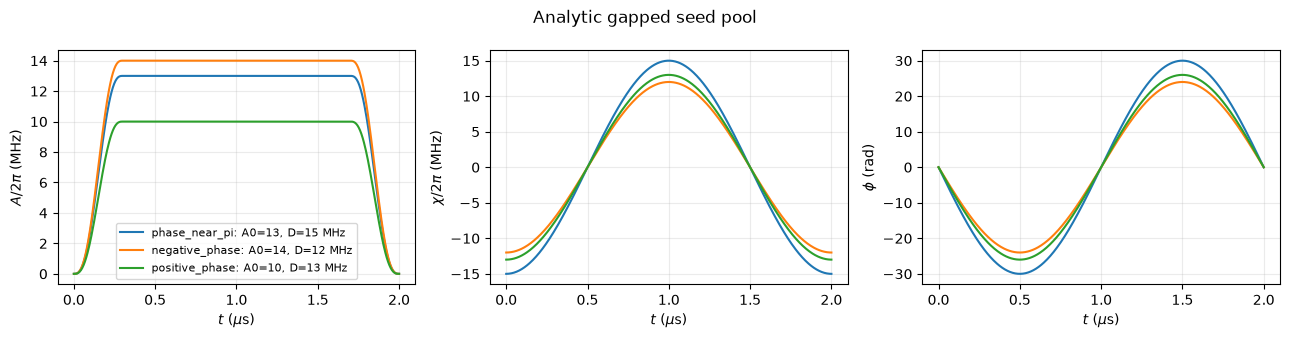

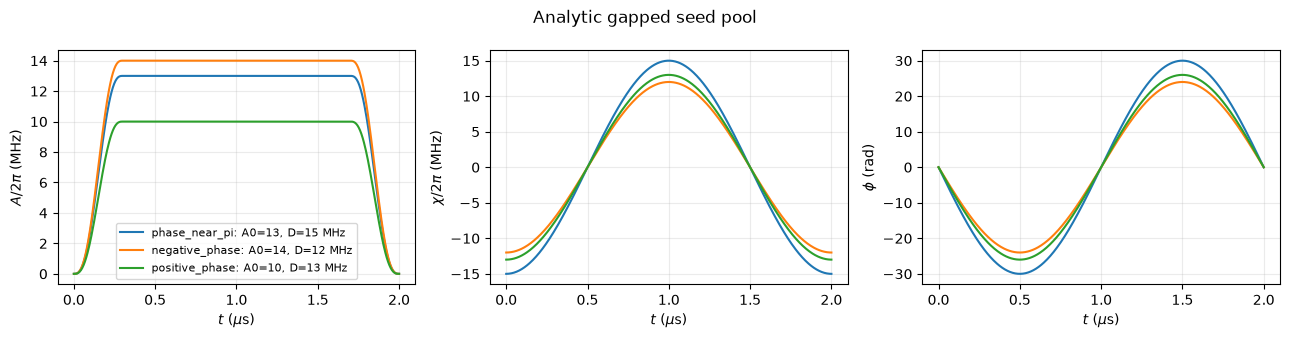

In [4]:
def pulse_arrays(parameters, duration_s, basis=BASIS, n_points=501):
    t = np.linspace(0.0, duration_s, n_points)
    amplitude, chirp = basis.controls(parameters, t / duration_s)
    phase = np.r_[0.0, cumulative_trapezoid(chirp, t)]
    return t, amplitude, chirp, phase


fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharex=True)
for spec in SEED_SPECS:
    parameters = BASIS.seed(spec["amplitude_MHz"], spec["edge_chirp_MHz"])
    t, amplitude, chirp, phase = pulse_arrays(parameters, INITIAL_DURATION_S)
    label = f'{spec["branch"]}: A0={spec["amplitude_MHz"]:.0f}, D={spec["edge_chirp_MHz"]:.0f} MHz'
    axes[0].plot(t / 1e-6, amplitude / MHz, label=label)
    axes[1].plot(t / 1e-6, chirp / MHz)
    axes[2].plot(t / 1e-6, phase)

axes[0].set_ylabel(r"$A/2\pi$ (MHz)")
axes[1].set_ylabel(r"$\chi/2\pi$ (MHz)")
axes[2].set_ylabel(r"$\phi$ (rad)")
for ax in axes:
    ax.set_xlabel(r"$t$ ($\mu$s)")
    ax.grid(alpha=0.25)
axes[0].legend(fontsize=8)
fig.suptitle("Analytic gapped seed pool")
fig.tight_layout()
display(fig)

## 4. Finite-$V_{rr}$ spline-GRAPE through the `qoc` seam

The search Hamiltonian is the bilinear control model exported by
`ryd_gate.bilinear_control_model` (ADR-0024): the same compiler that serves
`simulate` supplies $h_0$ with the geometry-resolved blockade and the Hermitian
channel operators, so no hand-built matrices remain. Propagation and the
analytic gradient live in `qoc.grape`: piecewise-constant midpoint slices
(1 ns cap) with the discrete adjoint — forward states, backward costates
through the same slice propagators, exact Fréchet slice derivatives — pulled
back through the spline coordinates by the study-side `control_pullback`, so
the gradient cost stays independent of the number of coordinates. At 1 ns the
endpoint amplitudes agree with the previous CF4 engine to $\sim2\times10^{-5}$
on the seed pool, far below both acceptance thresholds. The grid contains the
envelope breakpoints and spline knots, and the selected pulse is re-evaluated
once with every step bisected.

In [5]:
def propagation_grid(duration_s, basis, max_step_s=PW_MAX_STEP_S):
    normalized_edges = np.unique(np.r_[0.0, 0.15, 0.85, 1.0, basis.knots])
    pieces = []
    for left, right in zip(normalized_edges[:-1], normalized_edges[1:]):
        n_steps = max(1, int(np.ceil(duration_s * (right - left) / max_step_s)))
        pieces.append(np.linspace(left, right, n_steps + 1)[:-1])
    return duration_s * np.r_[np.concatenate(pieces), 1.0]


def bisect_grid(grid):
    grid = np.asarray(grid, dtype=float)
    midpoints = 0.5 * (grid[:-1] + grid[1:])
    refined = np.empty(grid.size + midpoints.size)
    refined[0::2] = grid
    refined[1::2] = midpoints
    return refined


def search_evaluation(parameters, duration_s, basis, grid, model, *, gradient):
    """Gate metrics (and 17-coordinate gradient) through qoc's GRAPE engine.

    Controls are sampled at slice midpoints: u = A/2 on the E[r,1]:x
    quadrature and u = -chi on the E[r,r] diagonal channel; the spline chain
    rule lives entirely in the pullback.
    """
    grid = np.asarray(grid, dtype=float)
    midpoints_s = 0.5 * (grid[:-1] + grid[1:]) / duration_s
    captured = {}

    def control_map(named):
        amplitude, chirp = basis.controls(np.asarray(named["theta"], dtype=float), midpoints_s)
        return {"E[r,1]:x": 0.5 * amplitude, "E[r,r]": -chirp}

    def control_pullback(named, channel_gradients):
        _amp, _chirp, d_amplitude, d_chirp = basis.controls(
            np.asarray(named["theta"], dtype=float), midpoints_s, jacobian=True)
        return {"theta": 0.5 * channel_gradients["E[r,1]:x"] @ d_amplitude
                - channel_gradients["E[r,r]"] @ d_chirp}

    def terminal_objective(final_states):
        amplitudes = np.array([final_states[j][model["indices"][j]] for j in range(4)])
        metrics = gate_metrics(amplitudes)
        captured["metrics"] = metrics
        return metrics["cost"], objective_costates(amplitudes, metrics, model)

    named = {"theta": np.asarray(parameters, dtype=float)}
    engine = dict(
        h0=model["h0"], controls=model["controls"],
        initial_states=model["initial_states"], time_grid=grid,
        control_map=control_map, terminal_objective=terminal_objective)
    if gradient:
        _value, named_gradient = grape.value_and_grad(
            named, control_pullback=control_pullback, **engine)
        return captured["metrics"], named_gradient["theta"]
    grape.value(named, **engine)
    return captured["metrics"], None

## 5. Endpoint objective

For $b\in\{00,01,10,11\}$, $a_b=\langle b|U(T)|b\rangle$ and $L_b=1-|a_b|^2$.
The smooth return loss is $L_{\rm mean}$; final acceptance uses $L_{\max}$. The
gauge-invariant product is $q=a_{00}a_{11}a_{01}^{*}a_{10}^{*}$. To avoid
rewarding phase carried by a leaky amplitude, the search uses

$$
S_\phi=\frac{|q|-\operatorname{Re}q}{2}=|q|\,C_\phi^2,\qquad
P_\phi=\max\!\left(0,1-\frac{S_\phi}{0.25}\right)^2,
$$

and minimizes $J=L_{\rm mean}+P_\phi$. Once the minimum entangling threshold is
met, $P_\phi=0$; no preferred target angle such as $\pi$ remains.

In [6]:
def gate_metrics(amplitudes):
    amplitudes = np.asarray(amplitudes, dtype=complex)
    losses = 1.0 - np.abs(amplitudes) ** 2
    q = amplitudes[0] * amplitudes[3] * np.conj(amplitudes[1]) * np.conj(amplitudes[2])
    q_abs = np.sqrt(abs(q) ** 2 + 1e-30)
    s_phi = 0.5 * (q_abs - q.real)
    hinge = max(0.0, 1.0 - s_phi / S_PHI_MIN)
    phi_zz = float(np.angle(q))
    return {
        "amplitudes": amplitudes,
        "losses": losses,
        "q": q,
        "L_mean": float(np.mean(losses)),
        "L_max": float(np.max(losses)),
        "Phi_ZZ": phi_zz,
        "C_phi": float(abs(np.sin(0.5 * phi_zz))),
        "S_phi": float(s_phi),
        "phase_penalty": float(hinge * hinge),
        "cost": float(np.mean(losses) + hinge * hinge),
    }


def objective_costates(amplitudes, metrics, model):
    """Terminal costates dJ/d(conj psi_b) of J = L_mean + hinge^2.

    Each logical loss contributes -a_b/4; the phase-penalty part goes through
    the Wirtinger derivatives of S_phi = (|q| - Re q)/2 with
    q = a00 a11 conj(a01) conj(a10). Verified against central finite
    differences of the full seam chain (relative error ~1e-8).
    """
    a00, a01, a10, a11 = amplitudes
    d_abar = -amplitudes / 4.0
    hinge = max(0.0, 1.0 - metrics["S_phi"] / S_PHI_MIN)
    if hinge > 0.0:
        q = metrics["q"]
        q_abs = np.sqrt(abs(q) ** 2 + 1e-30)
        d_s_dq = 0.5 * (np.conj(q) / (2.0 * q_abs) - 0.5)
        d_q_dabar = np.array([0.0, a00 * a11 * np.conj(a10), a00 * a11 * np.conj(a01), 0.0])
        d_qbar_dabar = np.array([np.conj(a11) * a01 * a10, 0.0, 0.0, np.conj(a00) * a01 * a10])
        d_abar = d_abar + (-2.0 * hinge / S_PHI_MIN) * (
            d_s_dq * d_q_dabar + np.conj(d_s_dq) * d_qbar_dabar)
    costates = []
    for value, index in zip(d_abar, model["indices"]):
        costate = np.zeros(model["dim"], dtype=complex)
        costate[index] = value
        costates.append(costate)
    return costates


def gate_passes(metrics):
    return metrics["L_max"] <= L_MAX_ACCEPT and metrics["C_phi"] >= C_PHI_ACCEPT

## 6. One fixed-duration optimization stage

`qoc.minimize` (method `"l-bfgs-b"`) receives the analytic gradient and the
per-iteration recorder through its method options; a study-side memo shares one
`value_and_grad` propagation between the separate loss and gradient calls
(`qoc` itself never caches). Every accepted optimizer iteration is recorded for
diagnostics, not as a candidate archive. Each stage compares only the inherited
seed and the optimizer terminal point: a feasible point beats an infeasible
one; if both pass, lower $L_{\max}$ wins. The selected point is evaluated once
on the bisected search grid and its discrepancy recorded. There is no retry,
tolerance gate, or extra optimizer budget; the public exact backend decides
final acceptance.

In [7]:
def scalar_metrics(metrics):
    return {
        key: float(metrics[key])
        for key in ("cost", "L_mean", "L_max", "Phi_ZZ", "C_phi", "S_phi", "phase_penalty")
    }


def append_history(history, *, branch, duration_s, stage_index, stage_iteration,
                   parameters, metrics, point_kind, grid_level, wall_time_s):
    branch_iteration = sum(entry["branch"] == branch for entry in history)
    history.append({
        "global_iteration": len(history),
        "branch_iteration": branch_iteration,
        "stage_iteration": int(stage_iteration),
        "branch": branch,
        "duration_s": float(duration_s),
        "stage_index": int(stage_index),
        "point_kind": point_kind,
        "grid_level": grid_level,
        "wall_time_s": float(wall_time_s),
        "parameters": np.asarray(parameters, dtype=float).tolist(),
        **scalar_metrics(metrics),
    })


def optimize_fixed_duration(parameters_seed, duration_s, *, branch, stage_index,
                            basis, history, grid, grid_level, model):
    started = time.perf_counter()
    cache = {"key": None, "metrics": None, "gradient": None}

    seed_metrics, _ = search_evaluation(
        parameters_seed, duration_s, basis, grid, model, gradient=False)
    append_history(
        history, branch=branch, duration_s=duration_s, stage_index=stage_index,
        stage_iteration=0, parameters=parameters_seed, metrics=seed_metrics,
        point_kind="seed", grid_level=grid_level, wall_time_s=0.0)

    # One propagation serves both the loss and the gradient: qoc never caches
    # (ADR-0023), so this explicit study-side memo shares the single
    # value_and_grad evaluation between qoc's separate loss/gradient calls.
    def evaluate(named):
        theta = np.asarray(named["theta"], dtype=float)
        key = theta.tobytes()
        if cache["key"] != key:
            metrics, gradient_value = search_evaluation(
                theta, duration_s, basis, grid, model, gradient=True)
            cache.update(key=key, metrics=metrics, gradient=gradient_value)
        return cache

    iteration = 0

    def iteration_callback(named):
        nonlocal iteration
        iteration += 1
        theta = np.asarray(named["theta"], dtype=float)
        if cache["key"] == theta.tobytes():
            metrics = cache["metrics"]
        else:
            metrics, _ = search_evaluation(
                theta, duration_s, basis, grid, model, gradient=False)
        append_history(
            history, branch=branch, duration_s=duration_s, stage_index=stage_index,
            stage_iteration=iteration, parameters=theta, metrics=metrics,
            point_kind="iteration", grid_level=grid_level,
            wall_time_s=time.perf_counter() - started)

    lower = np.array([pair[0] for pair in basis.bounds()])
    upper = np.array([pair[1] for pair in basis.bounds()])
    result = qoc.minimize(
        lambda named: evaluate(named)["metrics"]["cost"],
        {"theta": np.asarray(parameters_seed, dtype=float)},
        method="l-bfgs-b",
        bounds={"theta": (lower, upper)},
        options={
            **OPTIMIZER_OPTIONS,
            "gradient": lambda named: {"theta": evaluate(named)["gradient"]},
            "iteration_callback": iteration_callback,
        },
    )
    optimized_parameters = np.asarray(result.best_parameters["theta"], dtype=float)
    optimized_metrics, _ = search_evaluation(
        optimized_parameters, duration_s, basis, grid, model, gradient=False)
    optimizer_record = {
        "success": bool(result.success),
        "message": str(result.message),
        "nit": int(result.n_iterations),
        "nfev": int(result.n_evaluations),
        "wall_time_s": float(time.perf_counter() - started),
    }
    return {
        "seed_parameters": np.asarray(parameters_seed).copy(),
        "seed_metrics": seed_metrics,
        "optimized_parameters": optimized_parameters,
        "optimized_metrics": optimized_metrics,
        "optimizer": optimizer_record,
    }


def choose_two_points(search, *, fallback=False):
    candidates = (
        ("seed", search["seed_parameters"], search["seed_metrics"]),
        ("optimized", search["optimized_parameters"], search["optimized_metrics"]),
    )
    feasible = [c for c in candidates if gate_passes(c[2])]
    if feasible:
        return min(feasible, key=lambda c: c[2]["L_max"])
    if fallback:
        # Ladder mode never stalls: when neither point is feasible, carry the
        # lower-objective point forward (it is still exact-validated and the
        # stage is marked failed).
        return min(candidates, key=lambda c: c[2]["cost"])
    return None

## 7. Public exact-ODE validation and Rydberg exposure

Only the stage-selected pulse is converted back to the physical complex drive
$H_{r1}(t)=\tfrac{A(t)}{2}e^{-i\phi(t)}$, $\phi(t)=\int_0^t\chi(t')\,dt'$. A
single batched public call requests total Rydberg occupation at 301 times for
all four logical inputs; the same results provide the return amplitudes, so
exposure $\mathcal E_b=\int_0^T\langle n_{r,0}+n_{r,1}\rangle_b\,dt$ needs no
second evolution. Exact validation is far slower than a GRAPE evaluation and is
never run inside L-BFGS-B.

In [8]:
def physical_protocol(parameters, duration_s, basis):
    def amplitude(t_s):
        return basis.controls(parameters, t_s / duration_s)[0]

    def chirp(t_s):
        return basis.controls(parameters, t_s / duration_s)[1]

    phase = phase_from_chirp(chirp, duration_s, n_samples=PHASE_SAMPLES)
    return DigitalAnalogProtocol(
        t_gate_s=duration_s,
        coupling_r1_rad_s=lambda t_s: 0.5 * amplitude(t_s) * np.exp(-1j * phase(t_s)),
    )


def exact_validate(parameters, duration_s, basis):
    protocol = physical_protocol(parameters, duration_s, basis)
    system = RydbergSystem(
        level_structure=level_structure("01r", ryd_level=RYD_LEVEL),
        register=REGISTER, protocol=protocol)
    n_r_total = sum(system.observables.n("r", site) for site in range(system.N))
    t_eval = np.linspace(0.0, duration_s, EXACT_TRAJECTORY_POINTS)
    results = simulate(
        system, list(LOGICAL_LABELS), backend="exact_ode", t_eval=t_eval,
        observables={"n_r_total": n_r_total}, backend_options=EXACT_OPTIONS)

    amplitudes = np.array([
        result.amplitude(labels) for result, labels in zip(results, LOGICAL_LABELS)])
    metrics = gate_metrics(amplitudes)
    # Adaptive ODE roundoff can make 1-|a|^2 negative by ~machine precision;
    # exact validation reports the corresponding physical loss as zero.
    physical_losses = np.maximum(metrics["losses"], 0.0)
    metrics["losses"] = physical_losses
    metrics["L_mean"] = float(np.mean(physical_losses))
    metrics["L_max"] = float(np.max(physical_losses))
    metrics["cost"] = metrics["L_mean"] + metrics["phase_penalty"]

    trapezoid = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
    exposures = np.array([
        trapezoid(result.expectation("n_r_total"), result.times) for result in results])
    metrics["exposures_s"] = exposures
    metrics["exposure_mean_s"] = float(np.mean(exposures))
    metrics["exposure_max_s"] = float(np.max(exposures))
    return metrics

In [9]:
def run_stage(parameters_seed, duration_s, *, branch, stage_index, basis,
              history, model, select_fallback=False):
    history_start = sum(entry["branch"] == branch for entry in history)
    grid = propagation_grid(duration_s, basis)
    search = optimize_fixed_duration(
        parameters_seed, duration_s, branch=branch, stage_index=stage_index,
        basis=basis, history=history, grid=grid, grid_level="N", model=model)
    selected = choose_two_points(search, fallback=select_fallback)

    stage = {
        "branch": branch,
        "stage_index": int(stage_index),
        "duration_s": float(duration_s),
        "n_coeffs": int(basis.n_coeffs),
        "grid_steps": int(len(grid) - 1),
        "optimizer": search["optimizer"],
        "history_start": history_start,
        "seed_parameters": search["seed_parameters"],
        "optimized_parameters": search["optimized_parameters"],
        "seed_metrics": search["seed_metrics"],
        "optimized_metrics": search["optimized_metrics"],
        "accepted": False,
    }
    if selected is None:
        stage["failure"] = "neither seed nor optimizer endpoint passed the search grid"
        return stage

    source, parameters, coarse_metrics = selected
    fine_grid = bisect_grid(grid)
    fine_metrics, _ = search_evaluation(
        parameters, duration_s, basis, fine_grid, model, gradient=False)
    grid_error = {
        "steps": int(len(fine_grid) - 1),
        "delta_L_max": float(fine_metrics["L_max"] - coarse_metrics["L_max"]),
        "delta_C_phi": float(fine_metrics["C_phi"] - coarse_metrics["C_phi"]),
    }
    exact_metrics = exact_validate(parameters, duration_s, basis)
    stage.update({
        "selected_source": source,
        "selected_parameters": np.asarray(parameters).copy(),
        "search_metrics": fine_metrics,
        "grid_error": grid_error,
        "exact_metrics": exact_metrics,
        "history_end": sum(entry["branch"] == branch for entry in history) - 1,
        "accepted": bool(gate_passes(exact_metrics)),
    })
    if not stage["accepted"]:
        stage["failure"] = "public exact_ode validation failed"
    return stage

## 8. Result schema, caching, and atomic persistence

One human-readable artifact, `results/01r_adiabatic_optimization/result.json`,
is sufficient to recreate every table and figure without recomputation. Waveforms
are reconstructed from the 17 saved spline coordinates; no dense trajectories,
sampled waveforms, NPZ, or PNG files are stored. Only finite JSON is written
(`allow_nan=False`).

`serialize_stage` defines the **single** stage shape used by both fresh and
cached runs, so `stages` always holds plain JSON-safe records. `write_result`
replaces the file atomically and is called after every completed branch or
continuation attempt, so a later exception cannot discard in-memory history. A
partial run is flagged by `complete=False`.

In [10]:
def complex_record(value):
    value = complex(value)
    return {"real": float(value.real), "imag": float(value.imag)}


def metrics_record(metrics, *, exact):
    record = {
        **scalar_metrics(metrics),
        "amplitudes": [complex_record(v) for v in metrics["amplitudes"]],
        "losses": np.asarray(metrics["losses"]).tolist(),
        "q": complex_record(metrics["q"]),
    }
    if exact:
        record["exposures_s"] = np.asarray(metrics["exposures_s"]).tolist()
        record["exposure_mean_s"] = float(metrics["exposure_mean_s"])
        record["exposure_max_s"] = float(metrics["exposure_max_s"])
    return record


def serialize_stage(stage):
    """The one canonical JSON-safe stage record (fresh and cached share it)."""
    record = {
        "branch": stage["branch"],
        "stage_index": int(stage["stage_index"]),
        "duration_s": float(stage["duration_s"]),
        "n_coeffs": int(stage["n_coeffs"]),
        "grid_steps": int(stage["grid_steps"]),
        "optimizer": stage["optimizer"],
        "history_start": int(stage["history_start"]),
        "seed_parameters": np.asarray(stage["seed_parameters"], dtype=float).tolist(),
        "optimized_parameters": np.asarray(stage["optimized_parameters"], dtype=float).tolist(),
        "seed_metrics": metrics_record(stage["seed_metrics"], exact=False),
        "optimized_metrics": metrics_record(stage["optimized_metrics"], exact=False),
        "accepted": bool(stage["accepted"]),
    }
    if "failure" in stage:
        record["failure"] = stage["failure"]
    if "selected_parameters" in stage:
        record["selected_source"] = stage["selected_source"]
        record["selected_parameters"] = np.asarray(
            stage["selected_parameters"], dtype=float).tolist()
        record["search_metrics"] = metrics_record(stage["search_metrics"], exact=False)
        record["grid_error"] = stage["grid_error"]
        record["exact_metrics"] = metrics_record(stage["exact_metrics"], exact=True)
        record["history_end"] = int(stage["history_end"])
    return record


def build_config(c6_rad_s, v_rr_rad_s):
    return {
        "ryd_level": RYD_LEVEL,
        "spacing_um": SPACING_UM,
        "register_coords_um": REGISTER.coords.tolist(),
        "C6_rad_s_um6": float(c6_rad_s),
        "V_RR_rad_s": float(v_rr_rad_s),
        "amplitude_max_rad_s": float(A_MAX),
        "chirp_max_rad_s": float(CHI_MAX),
        "endpoint_chirp_min_rad_s": float(EDGE_CHIRP_MIN),
        "acceptance": {"L_max": L_MAX_ACCEPT, "C_phi": C_PHI_ACCEPT},
        "s_phi_min": S_PHI_MIN,
        "initial_duration_s": INITIAL_DURATION_S,
        "basis_n_coeffs": int(BASIS.n_coeffs),
        "basis_degree": int(BASIS.degree),
        "basis_knots": BASIS.knots.tolist(),
        "search_engine": "qoc.grape discrete adjoint (piecewise-constant midpoint slices)",
        "pw_max_step_s": PW_MAX_STEP_S,
        "phase_samples": PHASE_SAMPLES,
        "exact_trajectory_points": EXACT_TRAJECTORY_POINTS,
        "exact_options": EXACT_OPTIONS,
        "optimizer_options": OPTIMIZER_OPTIONS,
        "run_continuation": RUN_CONTINUATION,
        # Continuation semantics provenance: the duration ladder is the only mode.
        "continuation_mode": "ladder",
        "ladder_step_s": LADDER_STEP_S,
        "ladder_min_duration_s": LADDER_MIN_DURATION_S,
        "seed_specs": [dict(spec) for spec in SEED_SPECS],
    }


def build_payload(config, history, stages, complete):
    return {
        "schema_version": SCHEMA_VERSION,
        "kind": "two_atom_01r_computational_return_pulse",
        "complete": bool(complete),
        "config": config,
        "history": list(history),
        "stages": list(stages),
    }


def write_result(path, payload):
    path.parent.mkdir(parents=True, exist_ok=True)
    text = json.dumps(payload, indent=2, allow_nan=False) + "\n"
    tmp = path.with_name(path.name + ".tmp")
    tmp.write_text(text)
    tmp.replace(path)


def load_result(path):
    return json.loads(path.read_text())

## 9. Duration-ladder continuation (opt-in)

With `RUN_CONTINUATION=True`, each baseline branch is continued down a fixed
duration ladder: $0.1\,\mu\mathrm{s}$ steps from $1.9\,\mu\mathrm{s}$ to
$0.5\,\mu\mathrm{s}$ (16 stages per branch including the baseline). The
normalized coordinates are inherited unchanged: the $s=t/T$ parametrization
scales the pulse shape proportionally with $T$, so pulse area shrinks with
duration and is never rescaled automatically.

Each stage inherits the previous stage's *selected* coordinates and proceeds to
the next duration **regardless of acceptance** — stages are marked
accepted/failed but the branch never stalls. When neither the inherited seed
nor the optimizer terminal is feasible on the search grid, the lower-$J$ point
is selected, exact-validated, and carried forward. The purpose is diagnostic:
at every duration decrease the inherited pulse is less adiabatic (more residual
Rydberg population at the endpoint), so its objective $J$ should visibly jump
up before the optimizer pulls it back down.

The ladder does not prove a quantum speed limit. A failed duration of interest
can be manually retried with a richer $K=12$ spline basis (section 11
template).

In [11]:
def ladder_branch(baseline_record, *, basis, history, stages, model, save):
    """Fixed-step duration ladder; proceeds regardless of acceptance (never stalls)."""
    branch = baseline_record["branch"]
    if "selected_parameters" not in baseline_record:
        print(f"[{branch}] baseline has no selected point; skipping ladder")
        return
    current_parameters = baseline_record["selected_parameters"]
    n_steps = int(round((INITIAL_DURATION_S - LADDER_MIN_DURATION_S) / LADDER_STEP_S))

    for stage_index in range(1, n_steps + 1):
        trial_duration = INITIAL_DURATION_S - stage_index * LADDER_STEP_S
        print(f'[{branch}] ladder stage {stage_index}: T={trial_duration / 1e-6:.4f} us')
        trial = run_stage(
            current_parameters, trial_duration, branch=branch,
            stage_index=stage_index, basis=basis, history=history,
            model=model, select_fallback=True)
        record = serialize_stage(trial)
        stages.append(record)
        save(complete=False)
        exact = record["exact_metrics"]
        print(f'  {"accepted" if record["accepted"] else "failed"}: '
              f'Lmax={exact["L_max"]:.3e}, Cphi={exact["C_phi"]:.6f}')
        current_parameters = record["selected_parameters"]

## 10. Run or replay the three $T=2\,\mu\mathrm{s}$ branches

If `result.json` exists with the current `SCHEMA_VERSION` and
`FORCE_RECOMPUTE=False`, the cell loads it and skips all optimizer / exact_ode
/ ARC work. A cached result with an older schema (e.g. the pre-`qoc` CF4
engine, schema 3) is recomputed automatically. Otherwise it optimizes each
seed, records the bisected-grid discretization discrepancy, runs one complete
public exact validation, and atomically rewrites `result.json` after each
branch (and each continuation attempt), marking `complete=True` only at the
end.

In [12]:
def _report(record):
    if record.get("accepted") and "exact_metrics" in record:
        e = record["exact_metrics"]
        print(f'  accepted: Lmax={e["L_max"]:.3e}, Cphi={e["C_phi"]:.6f}, '
              f'PhiZZ={e["Phi_ZZ"]:+.6f} rad')
    elif "exact_metrics" in record:
        e = record["exact_metrics"]
        print(f'  rejected by exact_ode: Lmax={e["L_max"]:.3e}, Cphi={e["C_phi"]:.6f}')
    else:
        print("  failed:", record.get("failure", "unknown"))


def compute_result():
    c6, v_rr = resolve_interaction()
    model = build_search_model()
    # The exported h0 must carry the same signed ARC blockade as the recorded
    # config; the (0,1,r) local order puts |rr> at the last basis index.
    rr_index = model["dim"] - 1
    assert abs(model["h0"][rr_index, rr_index] - v_rr) <= 1e-9 * abs(v_rr)
    config = build_config(c6, v_rr)
    history, stages = [], []

    def save(*, complete):
        write_result(RESULT_PATH, build_payload(config, history, stages, complete))

    for spec in SEED_SPECS:
        print(f'[{spec["branch"]}] optimizing T = {INITIAL_DURATION_S / 1e-6:.3f} us')
        stage = run_stage(
            BASIS.seed(spec["amplitude_MHz"], spec["edge_chirp_MHz"]),
            INITIAL_DURATION_S, branch=spec["branch"], stage_index=0,
            basis=BASIS, history=history, model=model)
        record = serialize_stage(stage)
        stages.append(record)
        save(complete=False)
        _report(record)

    if RUN_CONTINUATION:
        for baseline in [s for s in stages if s["stage_index"] == 0]:
            ladder_branch(baseline, basis=BASIS, history=history, stages=stages,
                          model=model, save=save)

    save(complete=True)
    return config, history, stages


payload = None
if RESULT_PATH.exists() and not FORCE_RECOMPUTE:
    candidate = load_result(RESULT_PATH)
    if candidate.get("schema_version") == SCHEMA_VERSION:
        payload = candidate
    else:
        print(f'Cached result has schema {candidate.get("schema_version")}; '
              f'recomputing with schema {SCHEMA_VERSION}.')

if payload is not None:
    config, history, stages = payload["config"], payload["history"], payload["stages"]
    state = "complete" if payload.get("complete") else "PARTIAL (interrupted)"
    print(f"Loaded cached {state} result from {RESULT_PATH.relative_to(ROOT)}")
    print(f"  {len(stages)} stage(s), {len(history)} optimizer iteration(s); "
          f"no minimize / exact_ode / ARC calls.")
else:
    if RESULT_PATH.exists() and FORCE_RECOMPUTE:
        print("FORCE_RECOMPUTE=True: replacing the cached result with a new run.")
    config, history, stages = compute_result()
    print(f"Wrote {RESULT_PATH.relative_to(ROOT)}")

print(f"V_rr/2pi = {config['V_RR_rad_s'] / MHz:.6f} MHz")

Cached result has schema 3; recomputing with schema 4.


[phase_near_pi] optimizing T = 2.000 us


  accepted: Lmax=2.038e-10, Cphi=0.997405, PhiZZ=+2.997489 rad
[negative_phase] optimizing T = 2.000 us


  accepted: Lmax=1.988e-09, Cphi=0.565606, PhiZZ=-1.202336 rad
[positive_phase] optimizing T = 2.000 us


  accepted: Lmax=4.224e-11, Cphi=0.863124, PhiZZ=+2.082847 rad
Wrote results/01r_adiabatic_optimization/result.json
V_rr/2pi = 210.626400 MHz


In [13]:
def summary_table(stage_records):
    header = (
        "| branch | T (us) | source | exact Lmax | Cphi | PhiZZ (rad) | "
        "max exposure (us) | accepted |\n"
        "|---|---:|---|---:|---:|---:|---:|:---:|"
    )
    rows = [header]
    for stage in stage_records:
        exact = stage.get("exact_metrics")
        if exact is None:
            rows.append(
                f'| {stage["branch"]} | {stage["duration_s"] / 1e-6:.4f} | '
                f'— | — | — | — | — | no |')
            continue
        rows.append(
            f'| {stage["branch"]} | {stage["duration_s"] / 1e-6:.4f} | '
            f'{stage["selected_source"]} | {exact["L_max"]:.3e} | '
            f'{exact["C_phi"]:.6f} | {exact["Phi_ZZ"]:+.6f} | '
            f'{exact["exposure_max_s"] / 1e-6:.6f} | '
            f'{"yes" if stage["accepted"] else "no"} |')
    return "\n".join(rows)


display(Markdown(summary_table(stages)))

| branch | T (us) | source | exact Lmax | Cphi | PhiZZ (rad) | max exposure (us) | accepted |
|---|---:|---|---:|---:|---:|---:|:---:|
| phase_near_pi | 2.0000 | optimized | 2.038e-10 | 0.997405 | +2.997489 | 0.955462 | yes |
| negative_phase | 2.0000 | optimized | 1.988e-09 | 0.565606 | -1.202336 | 0.942520 | yes |
| positive_phase | 2.0000 | optimized | 4.224e-11 | 0.863124 | +2.082847 | 0.962135 | yes |

## 11. Diagnostics

The first figure shows the objective and gate metrics over accepted optimizer
iterations. Canonical $\Phi_{ZZ}\in[-\pi,\pi]$ stays stored in `history`; only
the plotted per-branch trace is unwrapped. A thin gray connector joins the end
of each stage to the inherited-seed evaluation at the next (shorter) duration,
so the seed's objective jump at every duration decrease is visible before the
optimizer pulls it down. Durations are on the colorbar; the legend keeps only
the exact-validation markers, with accepted stages as filled markers and failed
attempts as open markers. The second figure reconstructs the
physical $A(t)$ and control phase $\phi(t)$ from every recorded coordinate point;
each duration has one color, accepted iterations are thin, and each selected
pulse is thick (dashed if the attempt was rejected). The horizontal axis is real
physical time, so duration compression moves the pulse endpoint left.

Both figures consume the same JSON-shape `history` and `stages`, so they render
identically after a fresh computation and after a cached reload.

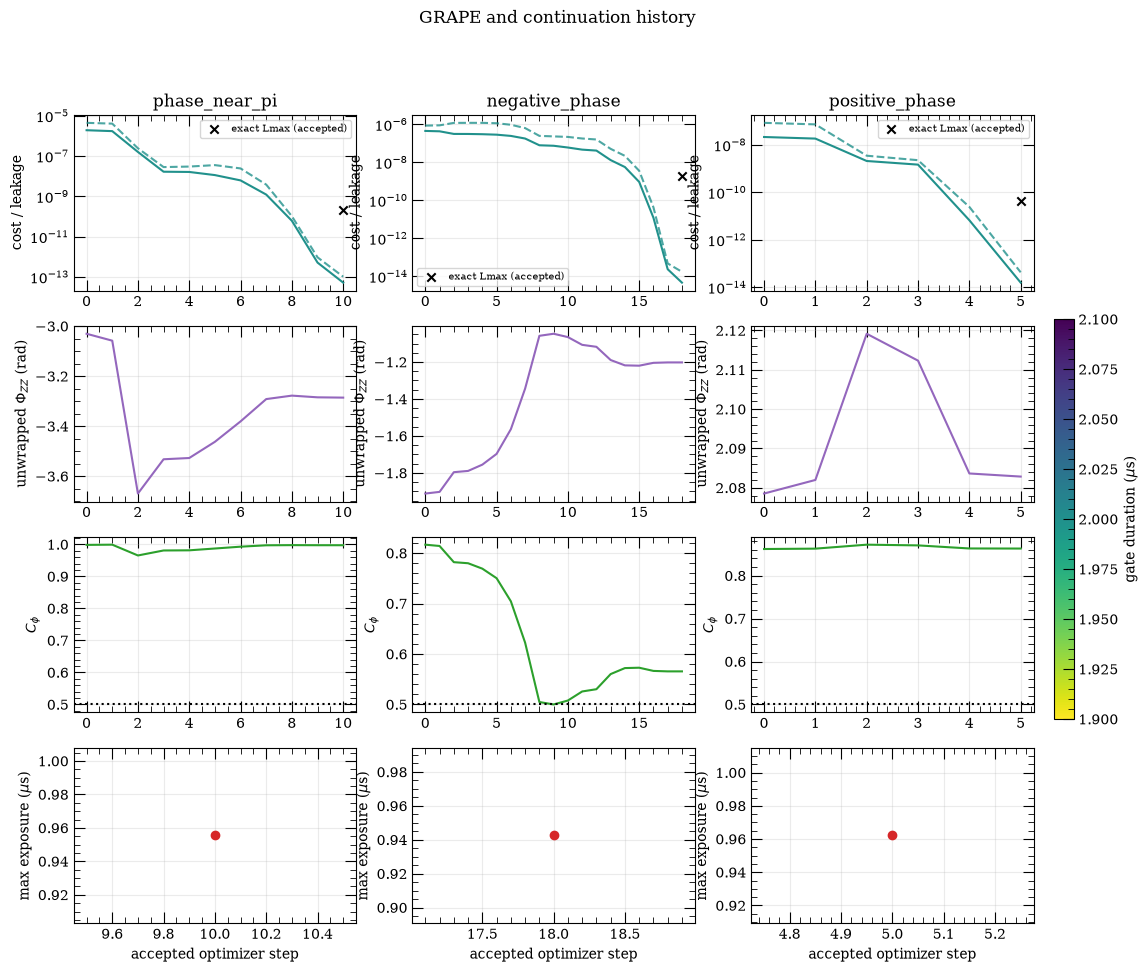

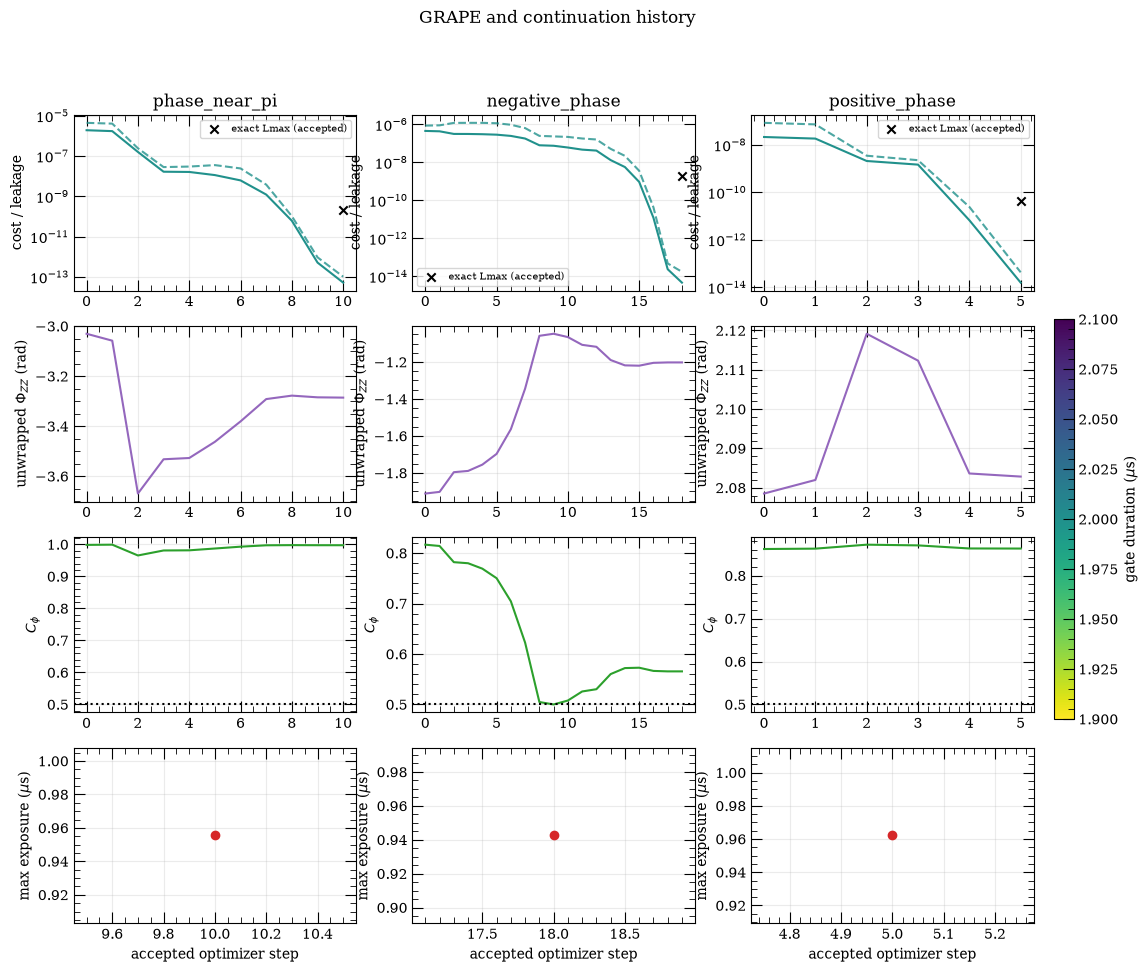

In [14]:
def duration_norm(records):
    durations = np.array([entry["duration_s"] for entry in records])
    low, high = float(np.min(durations)), float(np.max(durations))
    if np.isclose(low, high):
        pad = max(0.05 * high, 1e-12)
        low, high = low - pad, high + pad
    return colors.Normalize(vmin=low / 1e-6, vmax=high / 1e-6)


def _validated_stages(stages, branch):
    return [s for s in stages if s["branch"] == branch and "exact_metrics" in s]


def plot_metric_history(history, stages, basis=BASIS):
    branches = [spec["branch"] for spec in SEED_SPECS]
    norm = duration_norm(history) if history else colors.Normalize(0.0, 1.0)
    cmap = cm.viridis_r
    fig, axes = plt.subplots(
        4, len(branches), figsize=(4.3 * len(branches), 10.5), squeeze=False)

    for column, branch in enumerate(branches):
        records = [r for r in history if r["branch"] == branch]
        group_keys = []
        for record in records:
            key = (record["stage_index"], record["duration_s"])
            if key not in group_keys:
                group_keys.append(key)

        previous_tail = None
        for stage_index, duration_s in group_keys:
            group = [r for r in records
                     if r["stage_index"] == stage_index and r["duration_s"] == duration_s]
            x = np.array([r["branch_iteration"] for r in group])
            j = [max(r["cost"], 1e-16) for r in group]
            color = cmap(norm(duration_s / 1e-6))
            if previous_tail is not None:
                # Seed-jump connector: previous stage's last point to this
                # stage's inherited-seed evaluation at the shorter duration.
                axes[0, column].semilogy(
                    [previous_tail[0], x[0]], [previous_tail[1], j[0]],
                    color="0.65", lw=0.8, zorder=1)
            axes[0, column].semilogy(x, j, color=color)
            axes[0, column].semilogy(
                x, [max(r["L_max"], 1e-16) for r in group], "--", color=color, alpha=0.8)
            previous_tail = (x[-1], j[-1])

        if records:
            phi = np.unwrap([r["Phi_ZZ"] for r in records])
            xr = [r["branch_iteration"] for r in records]
            axes[1, column].plot(xr, phi, color="tab:purple")
            axes[2, column].plot(xr, [r["C_phi"] for r in records], color="tab:green")
        axes[2, column].axhline(C_PHI_ACCEPT, color="black", linestyle=":")

        exposure_points = []
        for stage in _validated_stages(stages, branch):
            x_stage = (stage["history_start"] if stage["selected_source"] == "seed"
                       else stage["history_end"])
            accepted = stage["accepted"]
            axes[0, column].scatter(
                [x_stage], [max(stage["exact_metrics"]["L_max"], 1e-16)],
                marker=("x" if accepted else "o"),
                color=("black" if accepted else "tab:red"),
                facecolors=("black" if accepted else "none"),
                label=("exact Lmax (accepted)" if accepted else "exact Lmax (failed)"),
                zorder=5)
            exposure_points.append(
                (x_stage, stage["exact_metrics"]["exposure_max_s"] / 1e-6, accepted))
        if exposure_points:
            exposure_points.sort()
            axes[3, column].plot(
                [p[0] for p in exposure_points], [p[1] for p in exposure_points],
                color="tab:red", lw=0.8, alpha=0.5, zorder=1)
            for x_stage, exposure, accepted in exposure_points:
                axes[3, column].plot(
                    [x_stage], [exposure], marker=("o" if accepted else "x"),
                    color="tab:red", fillstyle=("full" if accepted else "none"))

        axes[0, column].set_title(branch)
        axes[0, column].set_ylabel("cost / leakage")
        axes[1, column].set_ylabel(r"unwrapped $\Phi_{ZZ}$ (rad)")
        axes[2, column].set_ylabel(r"$C_\phi$")
        axes[3, column].set_ylabel(r"max exposure ($\mu$s)")
        axes[3, column].set_xlabel("accepted optimizer step")
        for row in range(4):
            axes[row, column].grid(alpha=0.25)
        # Durations are on the colorbar; the legend keeps only the deduplicated
        # exact-validation acceptance markers.
        handles, labels = axes[0, column].get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        if unique:
            axes[0, column].legend(unique.values(), unique.keys(), fontsize=7)

    colorbar = fig.colorbar(
        cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes, fraction=0.02, pad=0.02)
    colorbar.set_label(r"gate duration ($\mu$s)")
    fig.suptitle("GRAPE and continuation history")
    return fig


metric_figure = plot_metric_history(history, stages)
display(metric_figure)

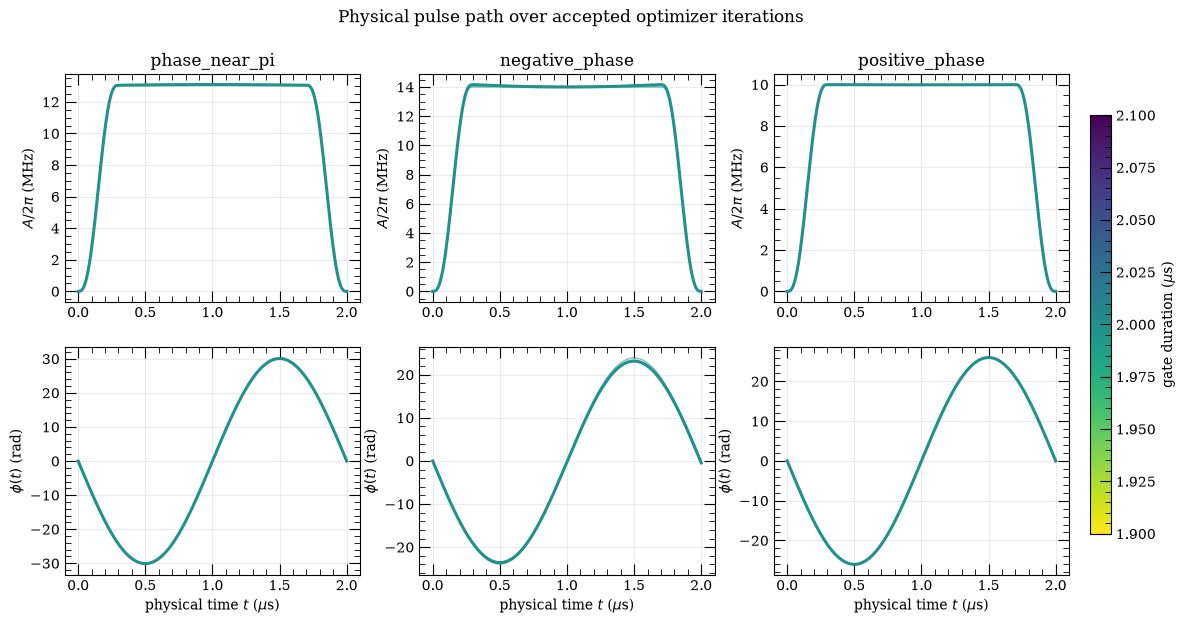

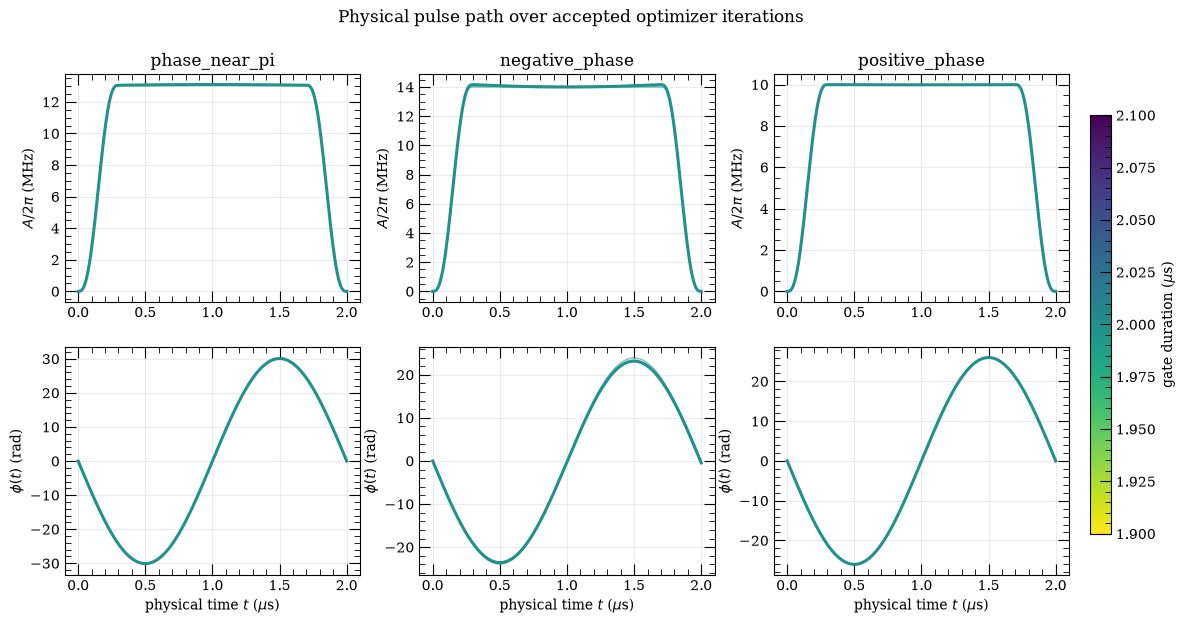

In [15]:
def plot_control_history(history, stages, basis=BASIS):
    branches = [spec["branch"] for spec in SEED_SPECS]
    norm = duration_norm(history) if history else colors.Normalize(0.0, 1.0)
    cmap = cm.viridis_r
    fig, axes = plt.subplots(
        2, len(branches), figsize=(4.5 * len(branches), 6.5), squeeze=False)

    for column, branch in enumerate(branches):
        for record in [r for r in history if r["branch"] == branch]:
            t, amplitude, _chirp, phase = pulse_arrays(
                record["parameters"], record["duration_s"], basis=basis, n_points=241)
            color = cmap(norm(record["duration_s"] / 1e-6))
            axes[0, column].plot(t / 1e-6, amplitude / MHz, color=color, lw=0.55, alpha=0.20)
            axes[1, column].plot(t / 1e-6, phase, color=color, lw=0.55, alpha=0.20)

        for stage in _validated_stages(stages, branch):
            t, amplitude, _chirp, phase = pulse_arrays(
                stage["selected_parameters"], stage["duration_s"], basis=basis, n_points=401)
            color = cmap(norm(stage["duration_s"] / 1e-6))
            style = "-" if stage["accepted"] else "--"
            width = 2.2 if stage["accepted"] else 1.5
            axes[0, column].plot(t / 1e-6, amplitude / MHz, style, color=color, lw=width)
            axes[1, column].plot(t / 1e-6, phase, style, color=color, lw=width)

        axes[0, column].set_title(branch)
        axes[0, column].set_ylabel(r"$A/2\pi$ (MHz)")
        axes[1, column].set_ylabel(r"$\phi(t)$ (rad)")
        axes[1, column].set_xlabel(r"physical time $t$ ($\mu$s)")
        for row in range(2):
            axes[row, column].grid(alpha=0.25)

    colorbar = fig.colorbar(
        cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes, fraction=0.02, pad=0.02)
    colorbar.set_label(r"gate duration ($\mu$s)")
    fig.suptitle("Physical pulse path over accepted optimizer iterations")
    return fig


control_figure = plot_control_history(history, stages)
display(control_figure)

### Optional spline-capacity check

For a failed duration of interest, the stage can be manually retried with
$K=12$ to distinguish a smooth-ansatz limit from the physics. It is
deliberately not automatic. The projection preserves the physical amplitude and
chirp coordinate functions in a least-squares sense.

In [16]:
def project_coordinates(parameters, old_basis, new_basis):
    s = np.linspace(0.0, 1.0, 401)
    old_B = old_basis.matrix(s)
    new_B = new_basis.matrix(s)
    old_p = np.asarray(parameters[: old_basis.n_coeffs])
    old_d = np.asarray(parameters[old_basis.n_coeffs : 2 * old_basis.n_coeffs])
    p_new = np.linalg.lstsq(new_B, old_B @ old_p, rcond=None)[0]
    d_new = np.linalg.lstsq(new_B, old_B @ old_d, rcond=None)[0]
    return np.r_[
        np.clip(p_new, 0.0, 1.0),
        np.clip(d_new, -3.0, 3.0),
        parameters[-1],
    ]


# Manual capacity-check template (needs a fresh compute with a fresh model):
# model = build_search_model()
# BASIS_12 = ControlBasis(n_coeffs=12)
# theta_12 = project_coordinates(theta_8, BASIS, BASIS_12)
# retry = run_stage(theta_12, failed_duration_s, branch="capacity_check",
#                   stage_index=0, basis=BASIS_12, history=[], model=model)

## 12. Reading the outcome

A successful baseline demonstrates a smooth finite-blockade phase gate, not
certified adiabaticity. The search intentionally allows intermediate Rydberg
population and does not penalize exposure. For a chosen stage inspect
`exact_metrics["L_max"]` (worst same-input return loss), `["C_phi"]` (periodic
entangling strength), `["Phi_ZZ"]` (canonical conditional phase), and
`["exposures_s"]` (four logical-input Rydberg exposures). Multiplying an exposure
by a chosen decay rate is a caller-owned first-order estimate; it is not folded
into the optimized endpoint objective.